In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/weapon_detection_project"
os.makedirs(project_path, exist_ok=True)

print("Project folder ready:", project_path)

Project folder ready: /content/drive/MyDrive/weapon_detection_project


In [ ]:
!pip install ultralytics roboflow matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
!pip install ultralytics
!pip install torch torchvision torchaudio
!pip install roboflow
!pip install opencv-python pillow
!pip install matplotlib seaborn
!pip install numpy pandas
!pip install scikit-learn
!pip install tqdm
!pip install pyyaml
!pip install deep-sort-realtime
!pip install moviepy
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 21.4 MB/s eta 0:00:00


In [ ]:
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("GPU:", torch.cuda.is_available())
print("OpenCV:", cv2.__version__)

model = YOLO("yolov8n.pt")
print("YOLO loaded successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128
GPU: True
OpenCV: 4.10.0
YOLO loaded successfully


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yUg3vkHtUQPvGCrcCRRx")
project = rf.workspace("abdzah").project("weapon-detection-smvsm-p5bwa")
version = project.version(1)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to WEAPON-DETECTION-1 in yolov12:: 100%|██████████| 46503/46503 [00:06<00:00, 7010.77it/s]


In [ ]:
dataset_path = dataset.location
print(dataset_path)

/content/WEAPON-DETECTION-1


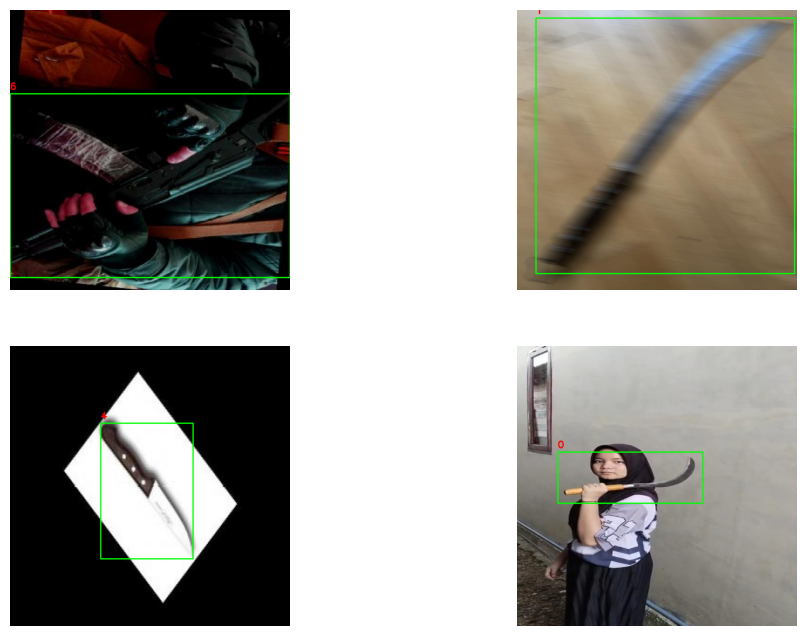

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

images_path = f"{dataset_path}/train/images"
labels_path = f"{dataset_path}/train/labels"

image_files = random.sample(os.listdir(images_path), 4)

plt.figure(figsize=(12, 8))

for i, image_file in enumerate(image_files):
    img_path = os.path.join(images_path, image_file)
    lbl_path = os.path.join(labels_path, image_file.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1),(x2,y2),(0,255,0),2)
                cv2.putText(img, str(int(cls)), (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0),2)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
model = YOLO("yolov8s.pt")

model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    project=project_path,
    name="baseline_yolov8s"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/WEAPON-DETECTION-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8s-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

KeyboardInterrupt: 

In [ ]:
!pip install ultralytics
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s/weights/best.pt")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s/results.csv")
print(df.tail())

   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  420.381         1.47057         2.59675         1.67337   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.68038            0.50315           0.59364   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.30219       1.74519       1.94616       1.97476  0.000303   

     lr/pg1    lr/pg2  
0  0.000303  0.000303  


In [ ]:
import os

base_path = "/content/drive/MyDrive/weapon_detection_project"

if not os.path.exists(base_path):
    print("❌ المسار غير موجود")
else:
    print(f"📂 Checking experiments in: {base_path}\n")

    experiments = os.listdir(base_path)

    if not experiments:
        print("❌ ما في أي تجارب محفوظة")
    else:
        for exp in experiments:
            exp_path = os.path.join(base_path, exp)

            if os.path.isdir(exp_path):
                weights_path = os.path.join(exp_path, "weights")

                print(f"🔹 Experiment: {exp}")

                if os.path.exists(weights_path):
                    files = os.listdir(weights_path)

                    if "best.pt" in files:
                        print("   ✅ best.pt موجود")

                    if "last.pt" in files:
                        print("   🔁 last.pt موجود")

                    if not files:
                        print("   ⚠️ فولدر weights فاضي")

                else:
                    print("   ❌ ما في weights folder")

                print()

📂 Checking experiments in: /content/drive/MyDrive/weapon_detection_project

🔹 Experiment: baseline_yolov8s
   ✅ best.pt موجود
   🔁 last.pt موجود

🔹 Experiment: baseline_yolov8s-2
   ✅ best.pt موجود
   🔁 last.pt موجود

🔹 Experiment: baseline_yolov8s-3
   ⚠️ فولدر weights فاضي

🔹 Experiment: baseline_yolov8s-4
   ⚠️ فولدر weights فاضي

🔹 Experiment: finetune_robust
   ⚠️ فولدر weights فاضي

🔹 Experiment: baseline_yolov8s-5
   ⚠️ فولدر weights فاضي

🔹 Experiment: finetuned_model
   ⚠️ فولدر weights فاضي

🔹 Experiment: fine_tuned_final
   ✅ best.pt موجود
   🔁 last.pt موجود

🔹 Experiment: baseline_yolov8s-6
   ⚠️ فولدر weights فاضي



In [ ]:
import pandas as pd

paths = [
    "/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s/results.csv",
    "/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/results.csv"
]

for path in paths:
    df = pd.read_csv(path)
    last = df.iloc[-1]

    print(f"\n📂 {path}")
    print(f"mAP50: {last['metrics/mAP50(B)']}")
    print(f"Precision: {last['metrics/precision(B)']}")
    print(f"Recall: {last['metrics/recall(B)']}")


📂 /content/drive/MyDrive/weapon_detection_project/baseline_yolov8s/results.csv
mAP50: 0.59364
Precision: 0.68038
Recall: 0.50315

📂 /content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/results.csv
mAP50: 0.92636
Precision: 0.91751
Recall: 0.87021


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/results.csv"

df = pd.read_csv(path)

last = df.iloc[-1]

print("📊 Final Results:")
print(f"mAP50: {last['metrics/mAP50(B)']}")
print(f"Precision: {last['metrics/precision(B)']}")
print(f"Recall: {last['metrics/recall(B)']}")

📊 Final Results:
mAP50: 0.92636
Precision: 0.91751
Recall: 0.87021


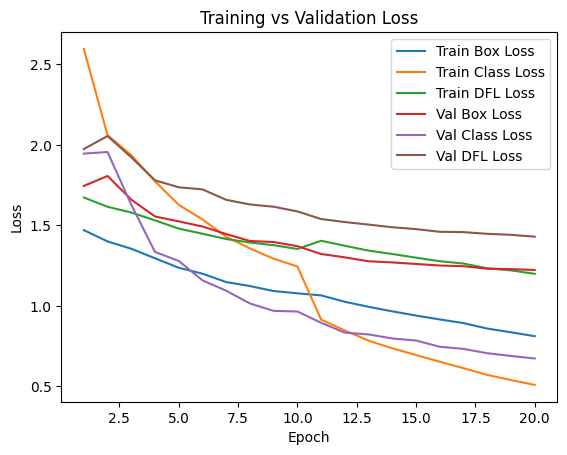

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Train losses
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")

# Validation losses
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Class Loss")
plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

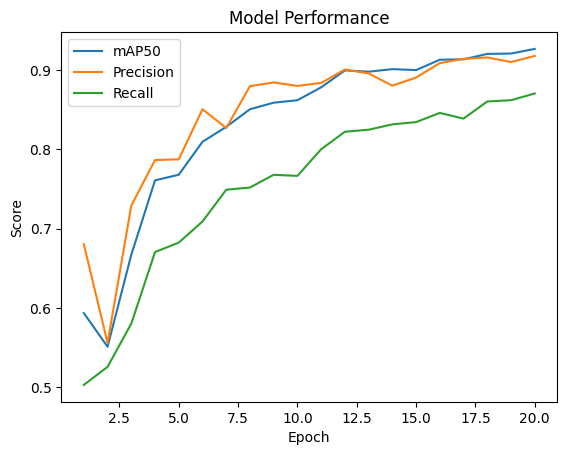

In [ ]:
plt.figure()

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model Performance")
plt.legend()
plt.show()

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/"))

['Untitled folder', 'washing', 'goha', 'washing car', '1tech', '2tech', 'work', '1x', 'he and she', 'pmp', 'orders', 'mattison final', 'inbound6465064441392076896.pdf', 'vgsales.csv', 'inbound8460696186042395734.pdf', 'CV ABDULLAHALZHNAN (1) (1).pdf', 'CV ABDULLAHALZHNAN (1).pdf', 'syrian', 'lemex presntation final copy2.pdf', 'inbound8252178090843689679.pdf', 'Be Creatively Smart (File responses)', 'Be Creatively Smart.gform', 'inbound7399682316673656385.pdf', '2.jpg', '1.jpg', 'cancer.jpg', 'ملخص كورس هندسة مطالبات ChatGPT\n (1).gdoc', 'ملخص كورس هندسة مطالبات ChatGPT\n.gdoc', 'Colab Notebooks', 'book shaiai2.pdf', 'book shaiai.pdf', 'PowerBI shaiai.pptx', 'book shai1-01.jpg', 'book shai2-04.jpg', 'shai ai.pptx', 'shai ai', 'IMG_20250508_153416.jpg', 'made in syria Final Project 1.pdf', 'inbound2746449297674334118.pdf', 'Google AI Studio', 'SPARTEK.pdf', 'spartek 2.pdf', 'New folder (2).zip', 'a4 .gdoc', 'a4.pdf', 'a4.gdoc', 'تجمع ورقة.pdf', 'تجمع ورقة.gdoc', 'youth imbact assembly p

In [ ]:
print(os.listdir("/content/drive/MyDrive/weapon_detection_project"))

['baseline_yolov8s', 'baseline_yolov8s-2', 'baseline_yolov8s-3', 'baseline_yolov8s-4', 'finetune_robust', 'baseline_yolov8s-5', 'finetuned_model']


In [ ]:
import yaml

with open("/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/args.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data["data"])

/content/WEAPON-DETECTION-1/data.yaml


In [ ]:
import pandas as pd

results = pd.read_csv("/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/results.csv")

print("آخر Epoch:")
print("mAP50:", results["metrics/mAP50(B)"].iloc[-1])
print("Precision:", results["metrics/precision(B)"].iloc[-1])
print("Recall:", results["metrics/recall(B)"].iloc[-1])

آخر Epoch:
mAP50: 0.92636
Precision: 0.91751
Recall: 0.87021


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/weights/best.pt")

model.train(
    data="/content/WEAPON-DETECTION-1/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,

    lr0=0.0005,

    patience=10,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    fliplr=0.5,
    mosaic=1.0,

    degrees=10,
    translate=0.1,
    scale=0.5,

    mixup=0.1,

    project="/content/drive/MyDrive/weapon_detection_project/",
    name="fine_tuned_final",
    exist_ok=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/WEAPON-DETECTION-1/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/weapon_detection_project/baseline_yolov8s-2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fine_tuned_final, nbs=

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/weapon_detection_project/fine_tuned_final/weights/last.pt")

model.train(
    resume=True
)

WARNING ⚠️ model '/content/drive/MyDrive/weapon_detection_project/fine_tuned_final/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

KeyboardInterrupt: 

In [ ]:
import pandas as pd

results = pd.read_csv("/content/drive/MyDrive/weapon_detection_project/fine_tuned_final/results.csv")

print("📊 آخر Epoch:\n")
print("mAP50:", results["metrics/mAP50(B)"].iloc[-1])
print("Precision:", results["metrics/precision(B)"].iloc[-1])
print("Recall:", results["metrics/recall(B)"].iloc[-1])

📊 آخر Epoch:

mAP50: 0.93275
Precision: 0.93434
Recall: 0.88147


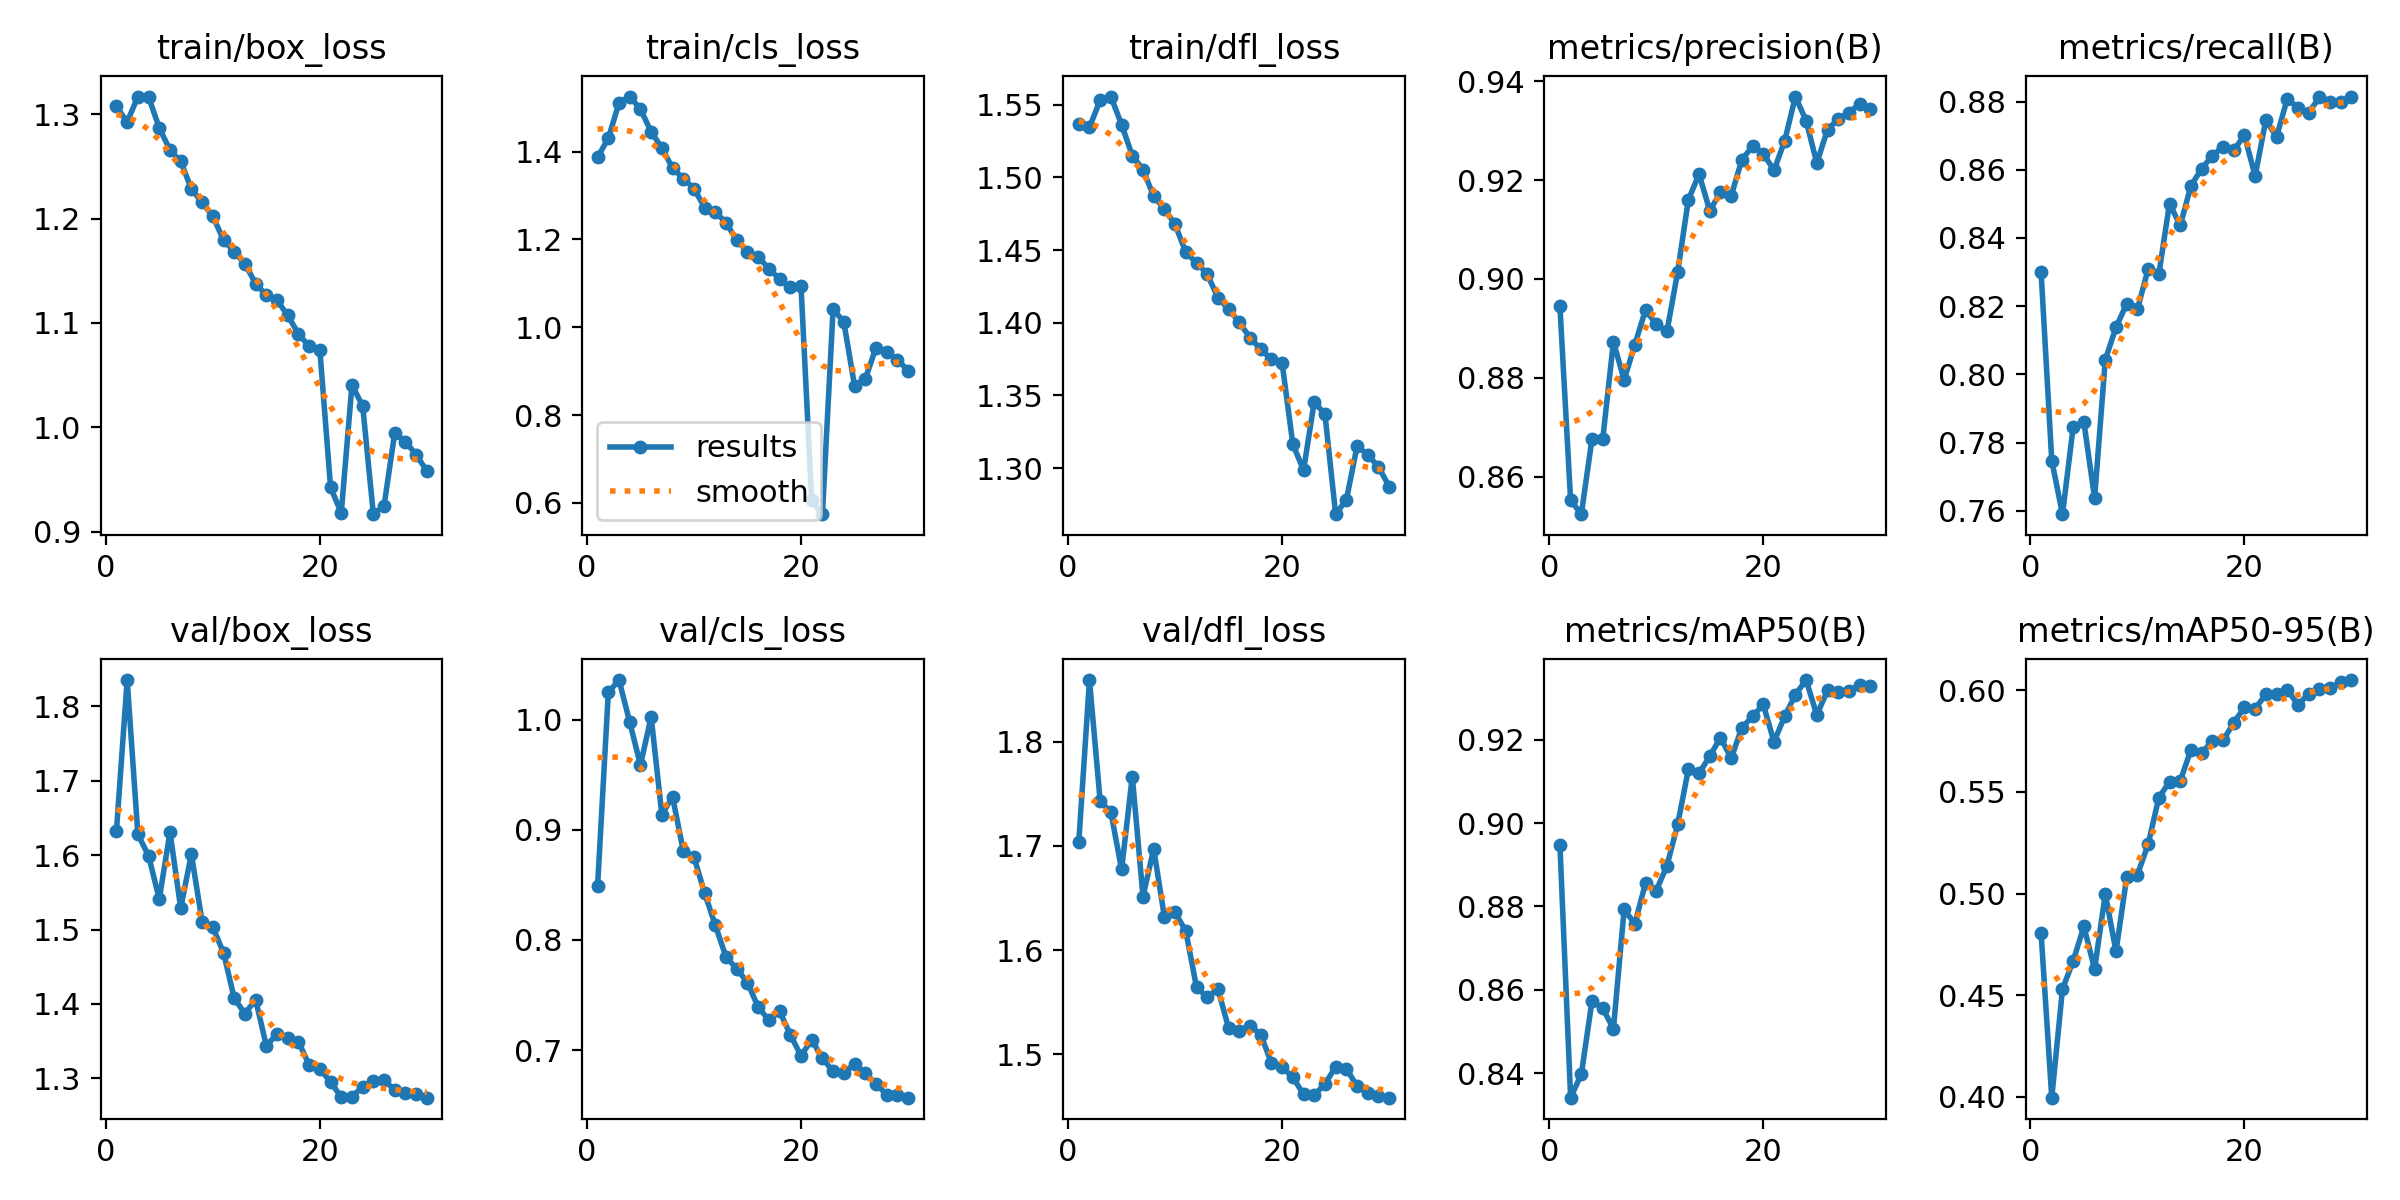

In [ ]:
from IPython.display import Image, display

display(Image("/content/drive/MyDrive/weapon_detection_project/fine_tuned_final/results.png"))

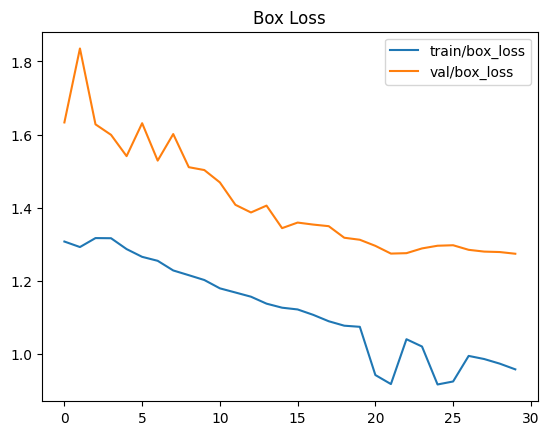

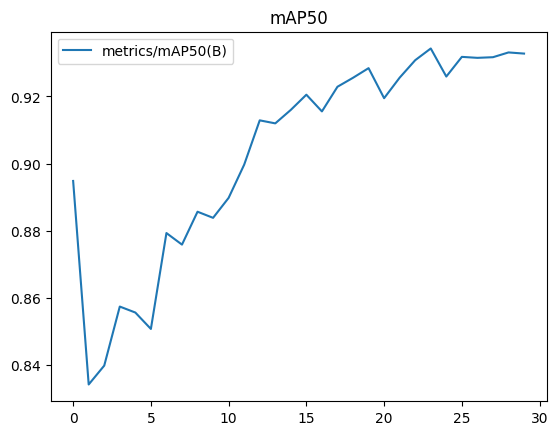

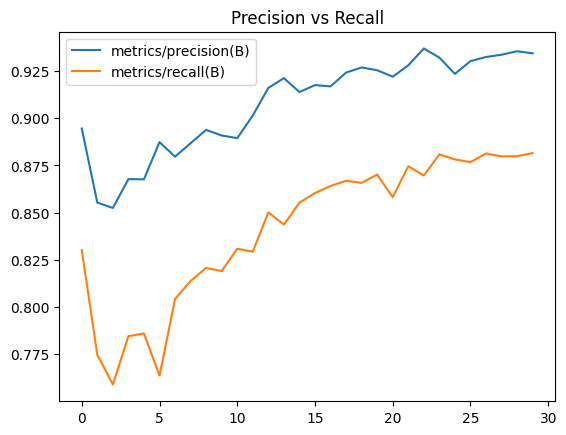

In [ ]:
import matplotlib.pyplot as plt

# Loss
results[["train/box_loss", "val/box_loss"]].plot(title="Box Loss")
plt.show()

# mAP
results[["metrics/mAP50(B)"]].plot(title="mAP50")
plt.show()

# Precision & Recall
results[["metrics/precision(B)", "metrics/recall(B)"]].plot(title="Precision vs Recall")
plt.show()